In [1]:
sample_secne = "scene-9f01d0565e051832"
label_file = f"/scratch/rksing18/stpp/AgentFormer/datasets/merged_nuscenes_waymo/label/train/{sample_secne}.txt"
meta_file = f"/scratch/rksing18/stpp/AgentFormer/datasets/merged_nuscenes_waymo/map_0.1/meta_{sample_secne}.txt"
map_file = f"/scratch/rksing18/stpp/AgentFormer/datasets/merged_nuscenes_waymo/map_0.1/{sample_secne}.png"
vis_map_file = f"/scratch/rksing18/stpp/AgentFormer/datasets/merged_nuscenes_waymo/map_0.1/vis_{sample_secne}.png"

In [2]:
import sys
import os
sys.path.append(os.getcwd())
from data.map import GeometricMap

In [ ]:
import numpy as np
data = np.genfromtxt(label_file, delimiter=' ', dtype="str")
meta = np.loadtxt(meta_file)
map_origin, scale = meta[:2], meta[2]
homography = np.array([[scale, 0., 0.], [0., scale, 0.], [0., 0., scale]])

import cv2
# scene_map = np.transpose(cv2.imread(map_file), (2, 0, 1))
scene_map = np.transpose(cv2.imread(map_file), (2, 1, 0))
scene_vis_map = np.transpose(cv2.cvtColor(cv2.imread(vis_map_file), cv2.COLOR_BGR2RGB), (2, 0, 1))
geom_scene_map = GeometricMap(scene_map, homography, map_origin)
scene_vis_map = GeometricMap(scene_vis_map, homography, map_origin)
data

array([['1.0', '1564.0', 'Car', ..., '34.65959', '1.546466', '0.0'],
       ['1.0', '1565.0', 'Car', ..., '-39.32196', '-1.6407002', '0.0'],
       ['1.0', '1566.0', 'Car', ..., '0.27345836', '-1.5946643', '0.0'],
       ...,
       ['91.0', '1632.0', 'Car', ..., '-82.68796', '1.54673', '0.0'],
       ['91.0', '1641.0', 'Car', ..., '-82.80877', '-4.7255287', '0.0'],
       ['91.0', '2037.0', 'Car', ..., '-128.16982', '-1.5864305', '0.0']],
      dtype='<U14')

In [4]:
unique_agents = np.unique(data[:, 1])
trajectories = {agent: data[data[:, 1] == agent][:, (13, 15)].astype(float) for agent in unique_agents}
first_agent = unique_agents[0]
print(f"Trajectories for agent {first_agent}:\n", trajectories[first_agent])

Trajectories for agent 1564.0:
 [[-808.37854    34.65959 ]
 [-808.3388     36.059853]
 [-808.3023     37.486984]
 [-808.26917    38.907864]
 [-808.2312     40.3441  ]
 [-808.19684    41.770622]
 [-808.169      43.150158]
 [-808.13385    44.616116]
 [-808.0854     46.10002 ]
 [-808.06934    47.519627]]


In [5]:
map_trajectories = {agent: geom_scene_map.to_map_points(traj) for agent, traj in trajectories.items()}

In [6]:
# Check if each row of the trajectory for all agents is smaller or larger than the origin
for agent, trajectory in trajectories.items():
    print(f"Agent {agent}:")
    for traj_row in trajectory:
        comparison = ["smaller" if traj_val < origin_val else "larger" for traj_val, origin_val in zip(traj_row, map_origin)]
        print(f"  Trajectory row {traj_row} is {comparison} compared to origin {map_origin}")

Agent 1564.0:
  Trajectory row [-808.37854   34.65959] is ['larger', 'larger'] compared to origin [-1005.  -452.]
  Trajectory row [-808.3388     36.059853] is ['larger', 'larger'] compared to origin [-1005.  -452.]
  Trajectory row [-808.3023     37.486984] is ['larger', 'larger'] compared to origin [-1005.  -452.]
  Trajectory row [-808.26917    38.907864] is ['larger', 'larger'] compared to origin [-1005.  -452.]
  Trajectory row [-808.2312   40.3441] is ['larger', 'larger'] compared to origin [-1005.  -452.]
  Trajectory row [-808.19684    41.770622] is ['larger', 'larger'] compared to origin [-1005.  -452.]
  Trajectory row [-808.169      43.150158] is ['larger', 'larger'] compared to origin [-1005.  -452.]
  Trajectory row [-808.13385    44.616116] is ['larger', 'larger'] compared to origin [-1005.  -452.]
  Trajectory row [-808.0854    46.10002] is ['larger', 'larger'] compared to origin [-1005.  -452.]
  Trajectory row [-808.06934    47.519627] is ['larger', 'larger'] compared 

In [7]:
# Print trajectories and map_trajectories row by row in the specified format
print("Trajectories and Map Trajectories:")
print(f"Map Origin: {map_origin}, Map Size: {geom_scene_map.as_image().shape}")
for traj_row, map_traj_row in zip(trajectories[first_agent], map_trajectories[first_agent]):
    print(f"{traj_row} -> {map_traj_row}")


Trajectories and Map Trajectories:
Map Origin: [-1005.  -452.], Map Size: (1071, 1863, 3)
[-808.37854   34.65959] -> [ 589.86438 1459.97877]
[-808.3388     36.059853] -> [ 589.9836   1464.179559]
[-808.3023     37.486984] -> [ 590.0931   1468.460952]
[-808.26917    38.907864] -> [ 590.19249  1472.723592]
[-808.2312   40.3441] -> [ 590.3064 1477.0323]
[-808.19684    41.770622] -> [ 590.40948  1481.311866]
[-808.169      43.150158] -> [ 590.493    1485.450474]
[-808.13385    44.616116] -> [ 590.59845  1489.848348]
[-808.0854    46.10002] -> [ 590.7438  1494.30006]
[-808.06934    47.519627] -> [ 590.79198  1498.558881]


In [8]:
geom_scene_map.as_image().shape

(1071, 1863, 3)

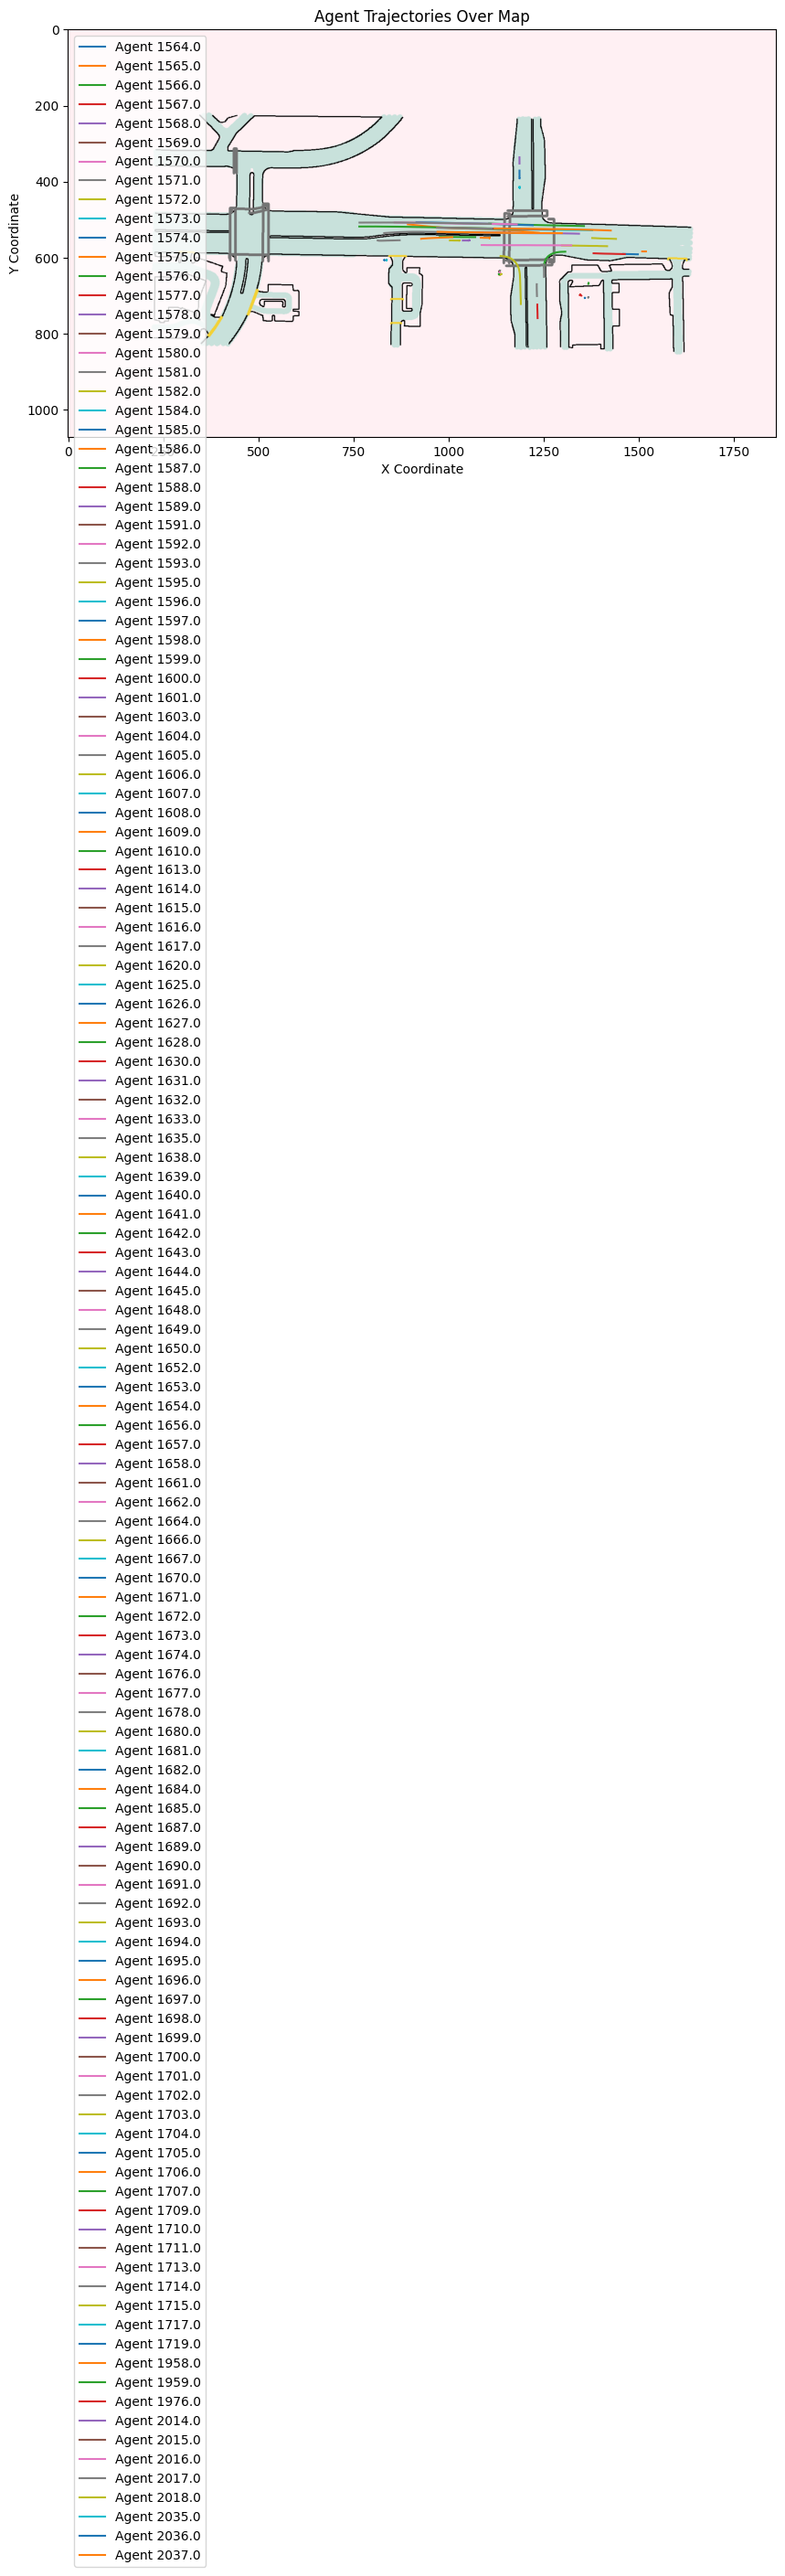

In [9]:
import matplotlib.pyplot as plt

# Use geom_scene_map.as_image() to get the map image
map_image = scene_vis_map.as_image()

# Plot the image
plt.figure(figsize=(10, 10))
plt.imshow(map_image) 

# plt.imshow(map_image, extent=[map_origin[0], map_origin[0] + map_image.shape[1], 
                            #   map_origin[1], map_origin[1] + map_image.shape[0]])

# Plot the trajectories of all agents
for agent, trajectory in map_trajectories.items():
    plt.plot(trajectory[:, 1], trajectory[:, 0], label=f'Agent {agent}')
    # plt.plot(trajectory[:, 0], trajectory[:, 1], label=f'Agent {agent}')

plt.legend()
plt.xlabel('X Coordinate')
plt.ylabel('Y Coordinate')
plt.title('Agent Trajectories Over Map')
plt.show()


In [9]:
trajectories[agent] = trajectories[agent][:, [1, 0]]
trajectories[agent]

array([[-1218.6146,  3637.0117],
       [-1218.6146,  3637.0117],
       [-1218.6146,  3637.0117],
       [-1218.6146,  3637.0117]])

In [11]:
for agent in unique_agents:
#     try:
    headings = data[data[:, 1] == agent][:, -2].astype(float)
    # geom_scene_map.get_cropped_maps(trajectories[agent][:, [1, 0]], [50, 10, 50, 90], -np.array(headings) * (180 / np.pi))
    geom_scene_map.get_cropped_maps(trajectories[agent], [50, 10, 50, 90], -np.array(headings) * (180 / np.pi))
    # except Exception as e:
    #     print(f"Error occurred for agent {agent}: {e}")

[-1005.  -452.] (3, 1863, 1071) torch.Size([3, 2373, 1581])
[-808.37854   34.65959] -> tensor([ 844, 1714])
[-808.3388     36.059853] -> tensor([ 844, 1719])
[-808.3023     37.486984] -> tensor([ 845, 1723])
[-808.26917    38.907864] -> tensor([ 845, 1727])
[-808.2312   40.3441] -> tensor([ 845, 1732])
[-808.19684    41.770622] -> tensor([ 845, 1736])
[-808.169      43.150158] -> tensor([ 845, 1740])
[-808.13385    44.616116] -> tensor([ 845, 1744])
[-808.0854    46.10002] -> tensor([ 845, 1749])
[-808.06934    47.519627] -> tensor([ 845, 1753])
context_padding (255, 255)
padded_map torch.Size([3, 2373, 1581])
---------------
map shape:  (3, 1863, 1071)
number of padded maps:  10
padded_map shape: 
padded_map[0]:  torch.Size([3, 2373, 1581])
padded_map[1]:  torch.Size([3, 2373, 1581])
padded_map[2]:  torch.Size([3, 2373, 1581])
padded_map[3]:  torch.Size([3, 2373, 1581])
padded_map[4]:  torch.Size([3, 2373, 1581])
padded_map[5]:  torch.Size([3, 2373, 1581])
padded_map[6]:  torch.Size([

RuntimeError: stack expects each tensor to be equal size, but got [3, 510, 122] at entry 0 and [3, 510, 117] at entry 1